# BrushCue Example: Pencil Sketch

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/pencil_sketch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/pencil-sketch

In [ ]:
!pip install brushcue

[wgpu] using backend Metal — adapter 'Apple M5' (IntegratedGpu), driver ''


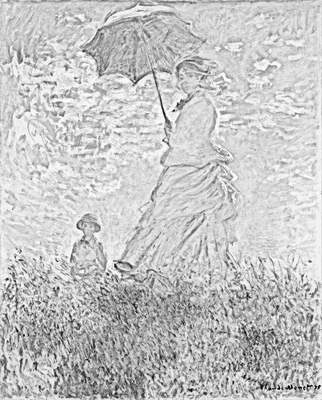

In [1]:
import io
from PIL import Image
import brushcue as bc


detail_size = 8.0
darkness = 1.25
paper_texture = 0.35
color_amount = 0.0
# Replace this with bc.Composition.from_path("your-photo.jpg") for your own image.
image = bc.Composition.monet_women_with_parasol()
bounds = image.bounds()
reference_scale = (
    bc.Float.max(1.0, bc.Float.min(bounds.width(), bounds.height())) / 1000.0
)
sigma = bc.Float.max(0.5, reference_scale * detail_size)
graph = image.spacial_effect_shader(
    "let p = clamp(position, image_bounds.xy + vec2f(0.5), image_bounds.zw - vec2f(0.5));\nlet source = sample(p);\nlet gray = luminance(source.rgb);\n// Alpha-weighted Gaussian neighborhood: transparent pixels contribute no color.\nvar total = 0.0;\nvar weights = 0.0;\nfor (var y = -4; y <= 4; y = y + 1) {\n    for (var x = -4; x <= 4; x = x + 1) {\n        let offset = vec2f(f32(x), f32(y));\n        let q = clamp(p + offset * sigma * 0.75, image_bounds.xy + vec2f(0.5), image_bounds.zw - vec2f(0.5));\n        let neighbor = sample(q);\n        let weight = exp(-dot(offset, offset) * 0.28125) * neighbor.a;\n        total += luminance(neighbor.rgb) * weight;\n        weights += weight;\n    }\n}\nlet local_gray = select(gray, total / max(weights, 0.0001), weights > 0.0001);\nlet dodge = clamp(gray / max(local_gray, 0.0001), 0.0, 1.0);\nlet line_ink = pow(1.0 - dodge, 0.65);\nlet shade_ink = pow(1.0 - gray, 1.6) * 0.18;\nlet ink = clamp((line_ink + shade_ink) * darkness, 0.0, 1.0);\nlet grain = paper_noise(floor((p - image_bounds.xy) / grain_scale));\nlet tooth = mix(1.0, 0.72 + 0.5 * grain, paper_texture);\nlet graphite = 1.0 - clamp(ink * tooth, 0.0, 1.0);\nlet paper = 1.0 - paper_texture * 0.035 * grain;\nlet pigment = mix(vec3f(1.0), source.rgb, color_amount * 0.65);\nreturn vec4f(clamp(vec3f(graphite * paper) * pigment, vec3f(0.0), vec3f(1.0)), source.a);",
    "fn luminance(rgb: vec3f) -> f32 {\n    return dot(clamp(rgb, vec3f(0.0), vec3f(1.0)), vec3f(0.299, 0.587, 0.114));\n}\nfn paper_noise(p: vec2f) -> f32 {\n    let q = fract(p * vec2f(0.1031, 0.11369));\n    let n = dot(q, q.yx + vec2f(19.19));\n    return fract((q.x + q.y + n) * (q.x + n));\n}",
    0.0,
    bc.Dictionary.create()
    .add("image_bounds", bounds)
    .add("sigma", sigma)
    .add("darkness", darkness)
    .add("paper_texture", paper_texture)
    .add("color_amount", color_amount)
    .add("grain_scale", bc.Float.max(0.5, reference_scale)),
    bc.ColorRepresentation.srgb(),
).crop(bounds)

ctx = bc.Context()
composition = graph.execute(ctx)
img = Image.open(io.BytesIO(composition.to_image_bytes(ctx)))
img.thumbnail((400, 400))
img
